# Generate PROTAC Fragments Based on Dictionaries

## Setup

In [7]:
import os
import sys
import pandas as pd

sys.path.append(os.path.join(os.getcwd(), '..', 'protac_splitter'))

from protac_splitter.data.curation import (
    update_dictionary,
    split_protacs,
    iterative_protac_splitting,
)
from protac_splitter.display_utils import get_mapped_protac_img

## Example

Some notes:

- There is no need to canonicalize the input SMILES, as the `update_dictionary` function will take care of that.
- The linkers sometimes are very small, so if used for substructure matching, they might "pollute" the splitting results, degrading the quality of the resulting fragments.

PROTAC n.  32: 100%|██████████| 33/33 [00:00<00:00, 48.81it/s, len_mapped=33, perc_mapped=100.0%]


,PROTAC SMILES,POI Ligand SMILES with direction,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES,E3 Binder SMILES,Linker SMILES,PROTAC ID,POI Ligand ID,E3 Binder ID,Linker ID,Notes
0,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]...,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1,O=C(CO[*:2])NCCOCCOCCOCCN[*:1],CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]...,O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1,NCCOCCOCCOCCNC(=O)CO,8547dc0538ae85f8dfa509f50c9173c8e77330d94d9e34...,8cb2ca4bab7fe90819de4467a66e5ef4c4ae31a7e789e5...,c73c9c28ffb34a4d5231a400cd1fe3b0c2b242c7c9ffc7...,b6ae099c7047a138907a1e06a3dd70d3b197bc9960390c...,(max_iter_on_linkers=0)(split_with_substr_and_...
1,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)NC1CCC...,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)NC1CCC...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1,O=C(CO[*:2])NCCOCCOCCOCCN[*:1],CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)NC1CCC...,O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1,NCCOCCOCCOCCNC(=O)CO,8547dc0538ae85f8dfa509f50c9173c8e77330d94d9e34...,8cb2ca4bab7fe90819de4467a66e5ef4c4ae31a7e789e5...,c73c9c28ffb34a4d5231a400cd1fe3b0c2b242c7c9ffc7...,b6ae099c7047a138907a1e06a3dd70d3b197bc9960390c...,(max_iter_on_linkers=0)(split_with_substr_and_...
2,Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C...,CN1CCN(c2ccc(-c3cccc(C(=O)[*:1])c3)cc2NC(=O)c2...,Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(N[*:2])...,O=C(CN[*:1])[*:2],CN1CCN(c2ccc(-c3cccc(C=O)c3)cc2NC(=O)c2c[nH]c(...,Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(N)C(C)(...,NCC=O,e3052468663e7c1de3afc94c9c30c2b8123276ea488af3...,7c5b4cb5a4e94238868625721e08b6be98ec447d76c646...,2d3021261081039315eaa3a025d0603825b75e9ca7661d...,38ec2cb7f80c10bbc9ab18fce315bbbdc3be53dd596dbb...,(max_iter_on_linkers=0)(split_with_substr_and_...
3,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,CC(C)c1ccn2ncnc(N[C@H]3CC[C@@H](N4CCN([*:1])CC...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,O=C(CCC(=O)[*:1])NCCCC(=O)[*:2],CC(C)c1ccn2ncnc(N[C@H]3CC[C@@H](N4CCNCC4)CC3)c12,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,O=CCCCNC(=O)CCC=O,fc65fa7315e8245f25f20cb22d2feab256d9fd775d0e86...,a7ba60fd0d729e23fa32304f42ee4b5aba43c4f72c3b8c...,2d3021261081039315eaa3a025d0603825b75e9ca7661d...,2e941fd97e40598180a90c3eb225f1dbe4bf782cdd5dde...,(max_iter_on_linkers=0)(split_with_substr_and_...
4,Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C...,CC(C)c1ccn2ncnc(NC3CCC(N4CCN([*:1])CC4)CC3)c12,Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(N[*:2])...,O=C(CCC(=O)[*:1])NCCCC(=O)[*:2],CC(C)c1ccn2ncnc(NC3CCC(N4CCNCC4)CC3)c12,Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(N)C(C)(...,O=CCCCNC(=O)CCC=O,fc65fa7315e8245f25f20cb22d2feab256d9fd775d0e86...,a7ba60fd0d729e23fa32304f42ee4b5aba43c4f72c3b8c...,2d3021261081039315eaa3a025d0603825b75e9ca7661d...,2e941fd97e40598180a90c3eb225f1dbe4bf782cdd5dde...,(max_iter_on_linkers=0)(split_with_substr_and_...
5,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]...,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1,O=C(CO[*:2])NCCOCCOCCN[*:1],CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]...,O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1,NCCOCCOCCNC(=O)CO,c72ad6324bb5335183267f135127ab1373f4e51990dfca...,8cb2ca4bab7fe90819de4467a66e5ef4c4ae31a7e789e5...,c73c9c28ffb34a4d5231a400cd1fe3b0c2b242c7c9ffc7...,e6942eff66ac4d2caeae5786dab992bda9975efea7bd23...,(max_iter_on_linkers=0)(split_with_substr_and_...
6,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)NC1CCC...,CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)NC1CCC...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1,O=C(CO[*:2])NCCOCCOCCN[*:1],CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)NC1CCC...,O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1,NCCOCCOCCNC(=O)CO,c72ad6324bb5335183267f135127ab1373f4e51990dfca...,8cb2ca4bab7fe90819de4467a66e5ef4c4ae31a7e789e5...,c73c9c28ffb34a4d5231a400cd1fe3b0c2b242c7c9ffc7...,e6942eff66ac4d2caeae5786dab992bda9975efea7bd23...,(max_iter_on_linkers=0)(split_with_substr_and_...
7,CN1C(=O)CCc2cc3cc(c21)OCCOC[C@H]1CN(C(=O)CCC(=...,C

--------------------------------------------------------------------------------
List of split PROTACs:
--------------------------------------------------------------------------------
    [
        'CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)NCCOCCOCCOCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1',
        'O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.O=C(CO[*:2])NCCOCCOCCOCCN[*:1].CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)[*:1])CC1',
    ],
    [
        'CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)NC1CCC(C(=O)NCCOCCOCCOCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1',
        'O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.O=C(CO[*:2])NCCOCCOCCOCCN[*:1].CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)NC1CCC(C(=O)[*:1])CC1',
    ],
    [
        'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CNC(=O)c2cccc(-c3ccc(N4CCN(C)CC4)c(NC(=O)c4c[nH]c(=O)cc4C(F)(F)F)c3)c2)C(C)(C)C)cc1',
        'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(N[*:2])C(C)(C)C)cc1.O=C(CN[*:1])[*:2].C

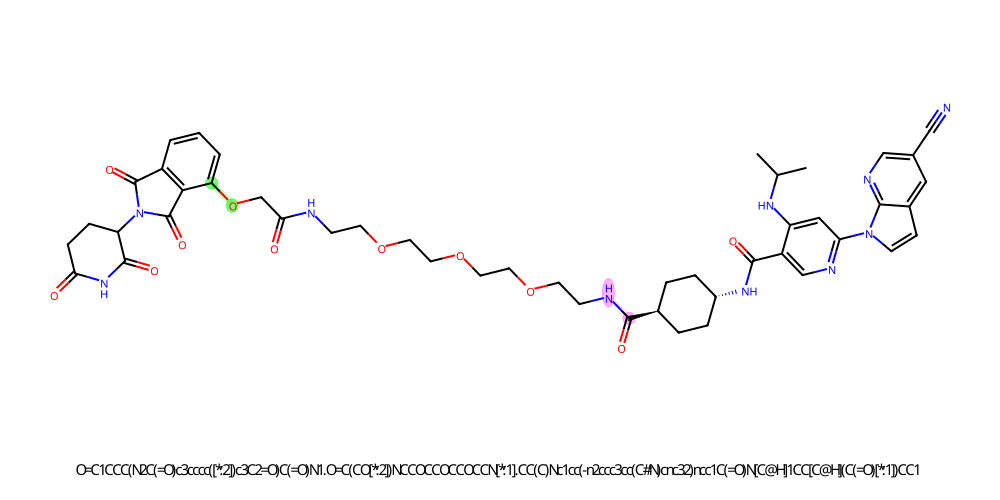

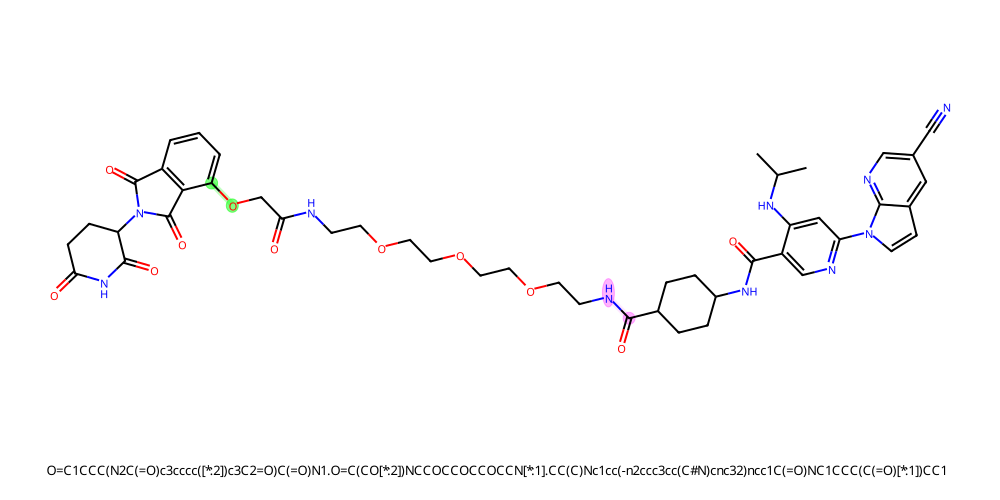

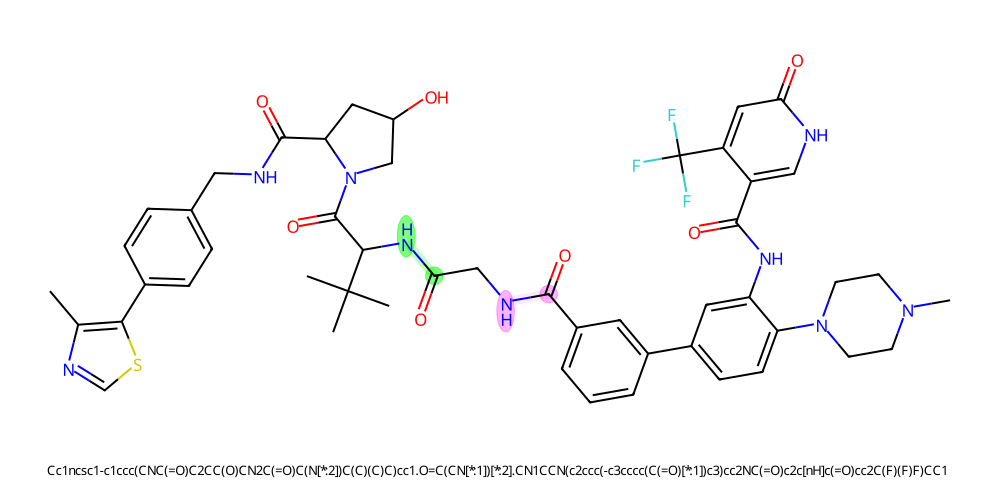

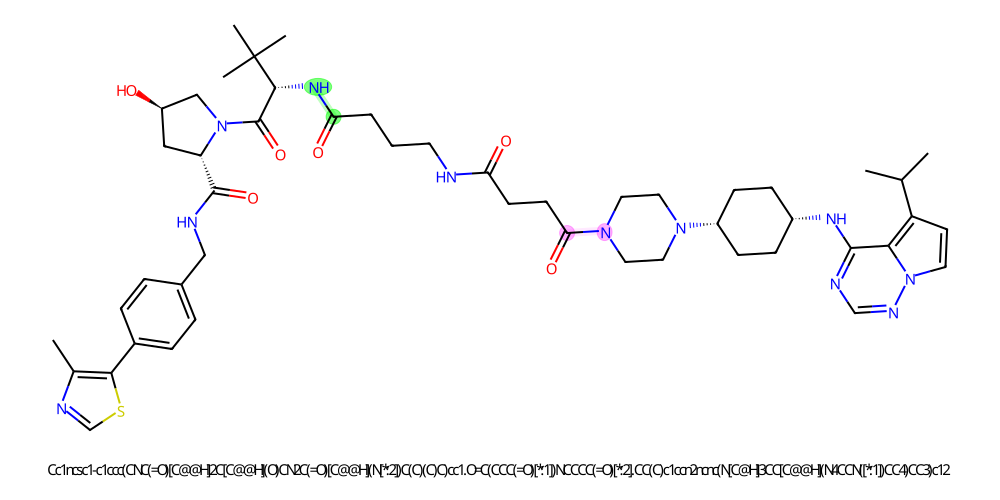

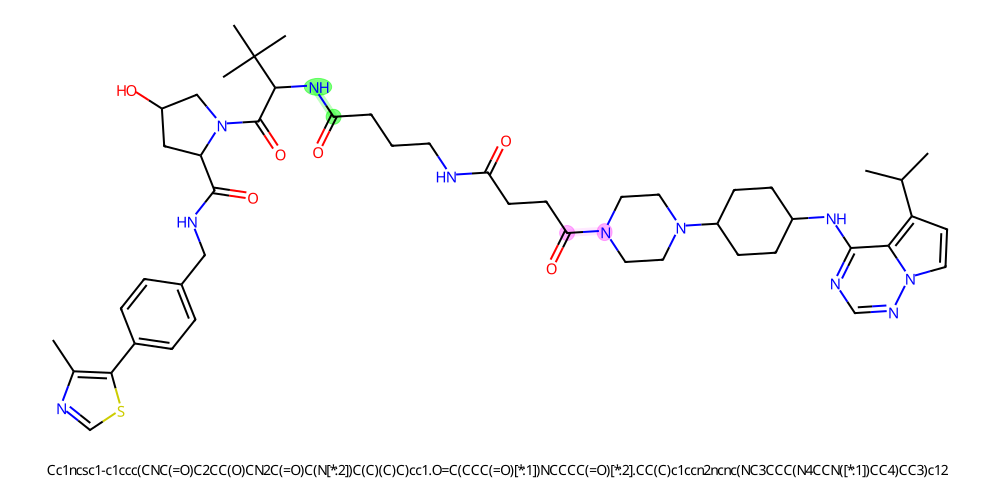

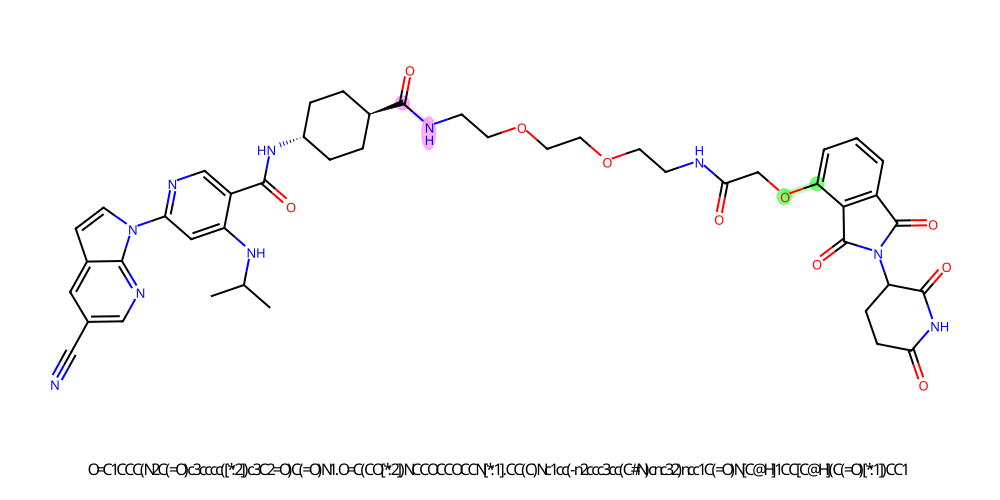

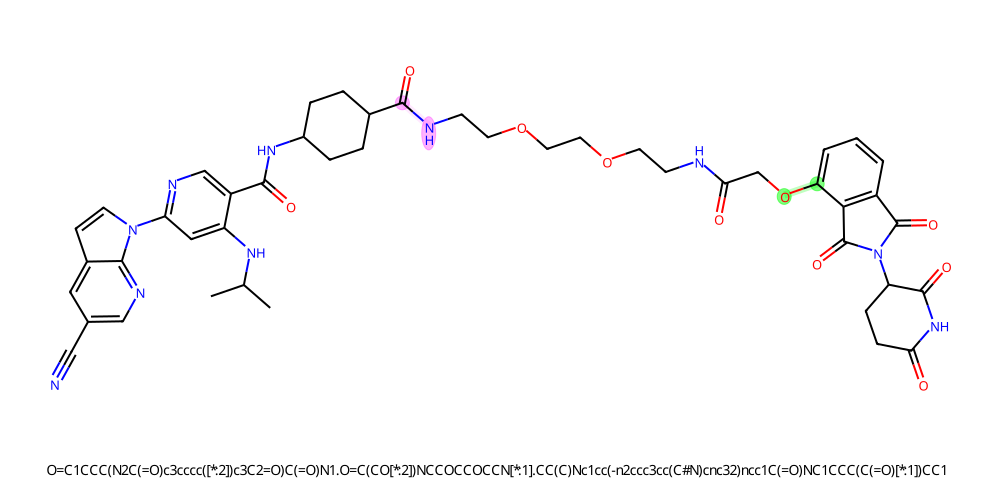

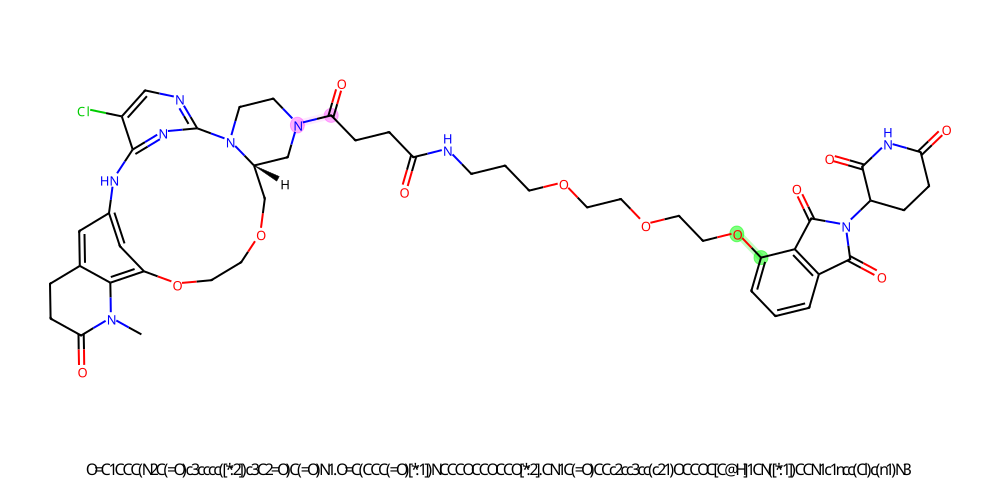

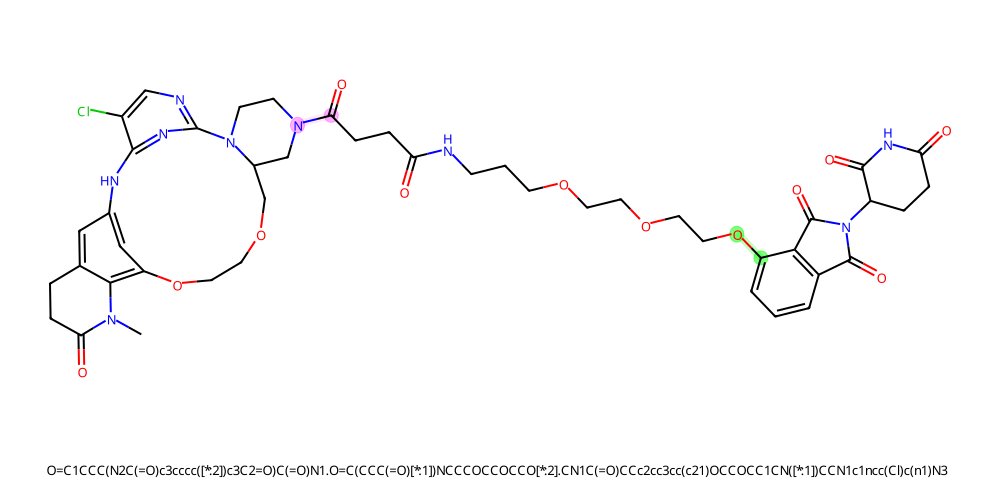

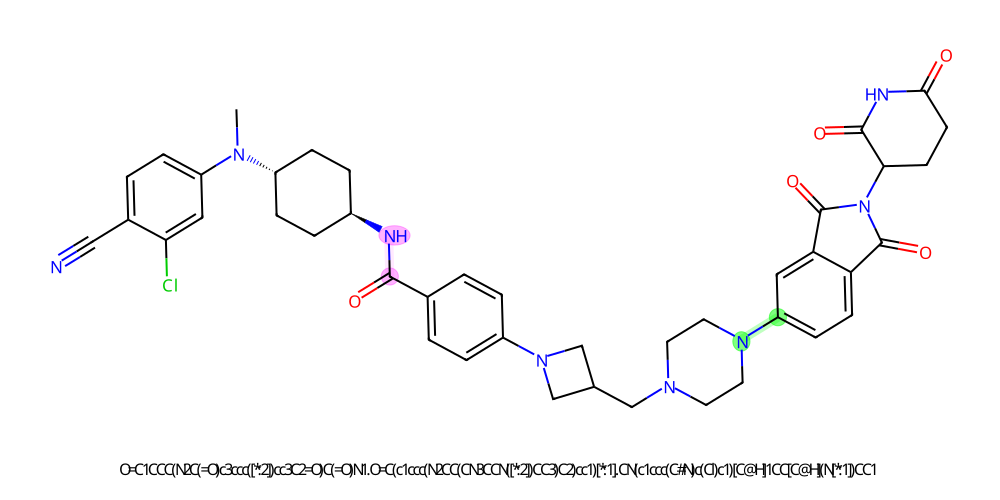

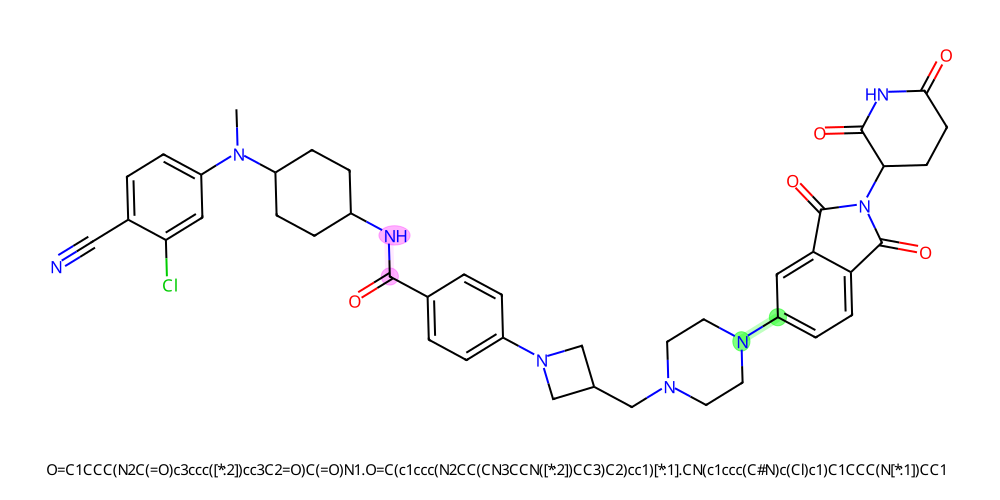

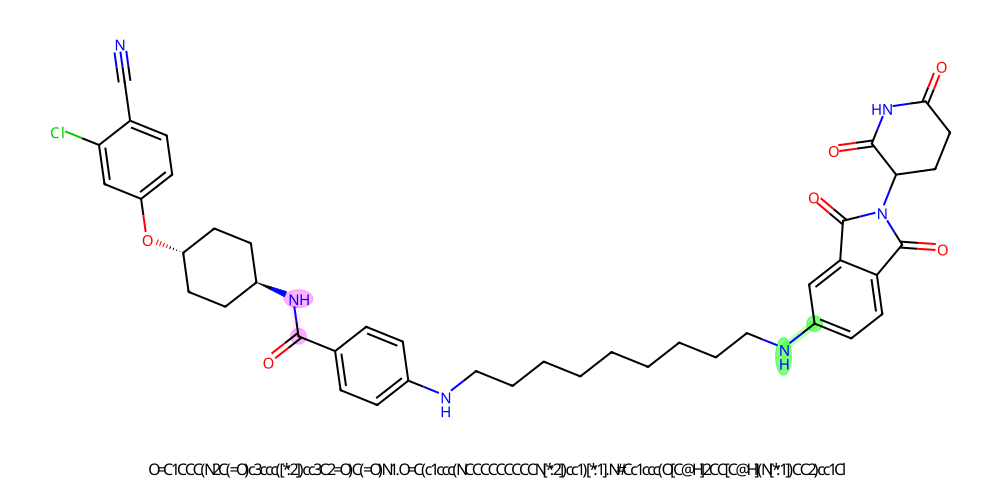

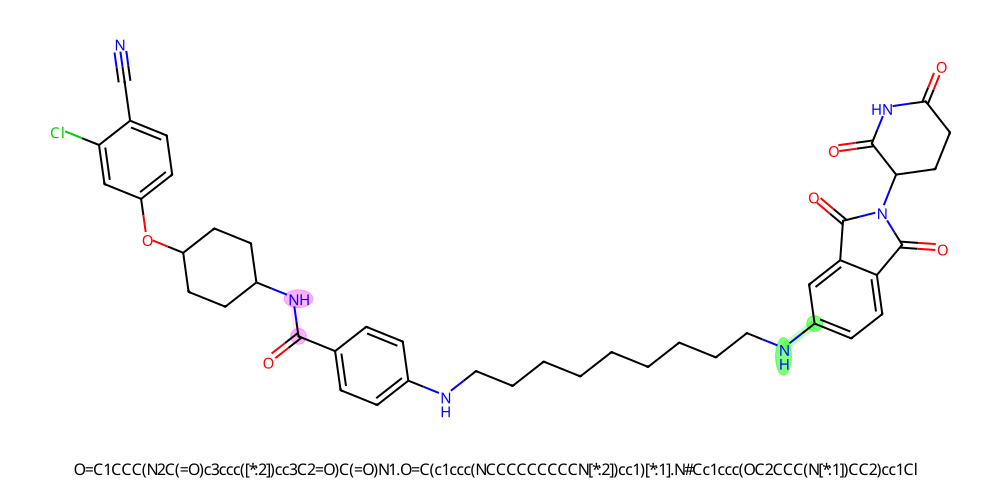

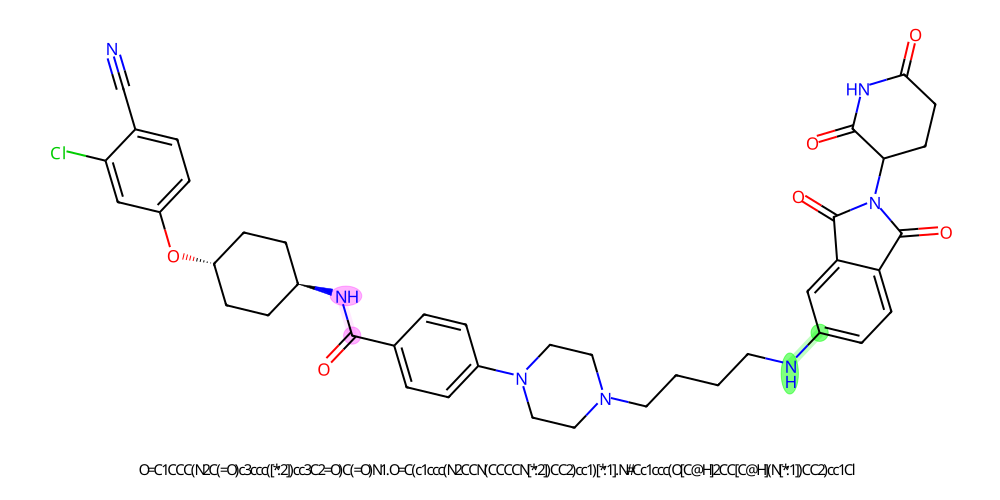

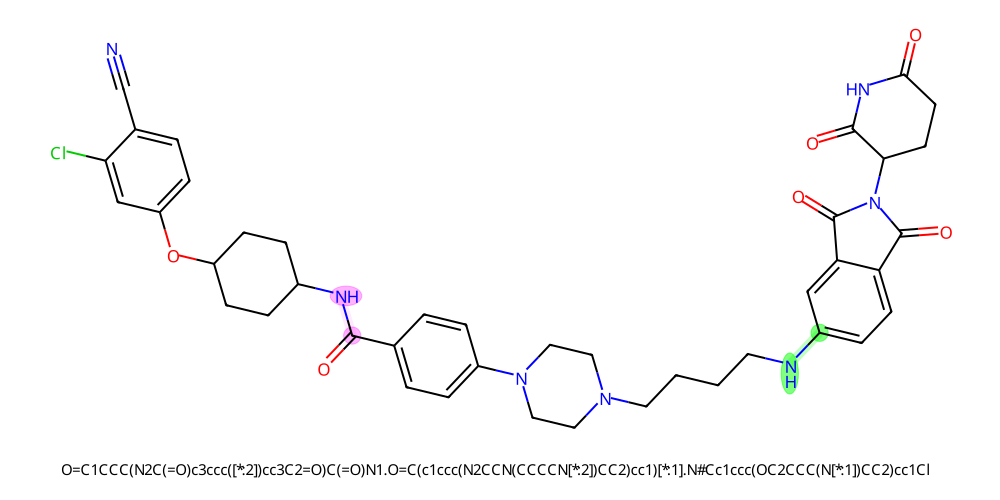

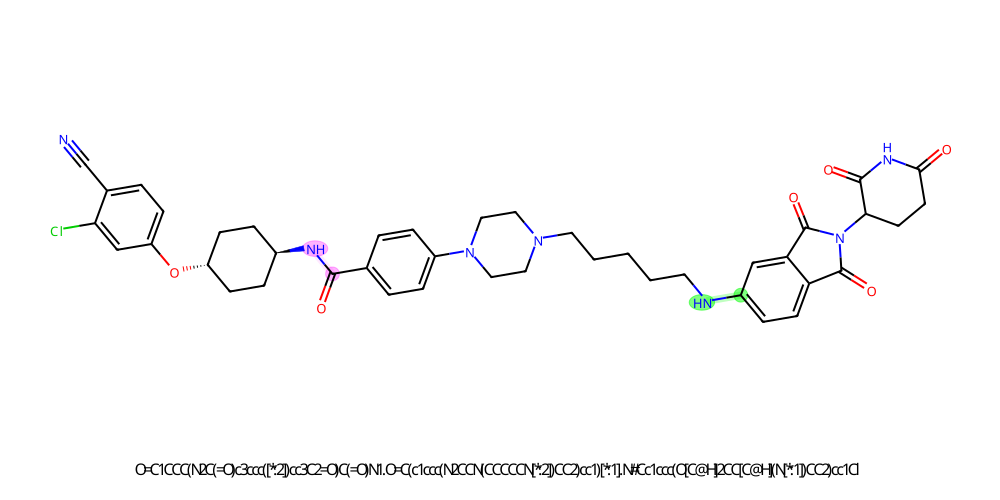

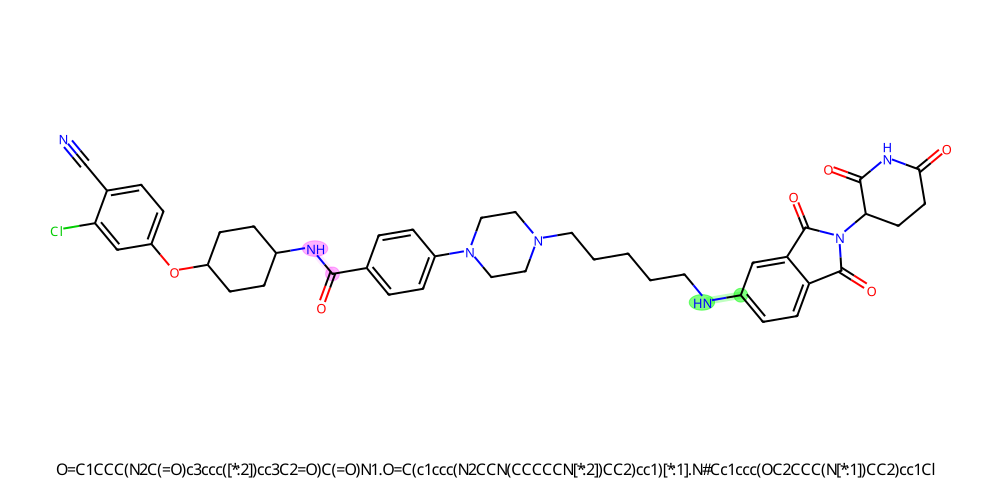

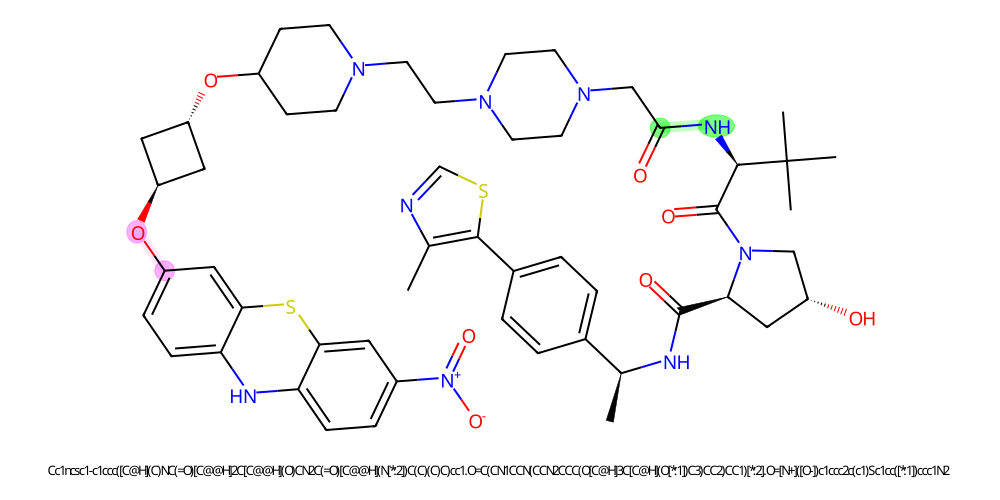

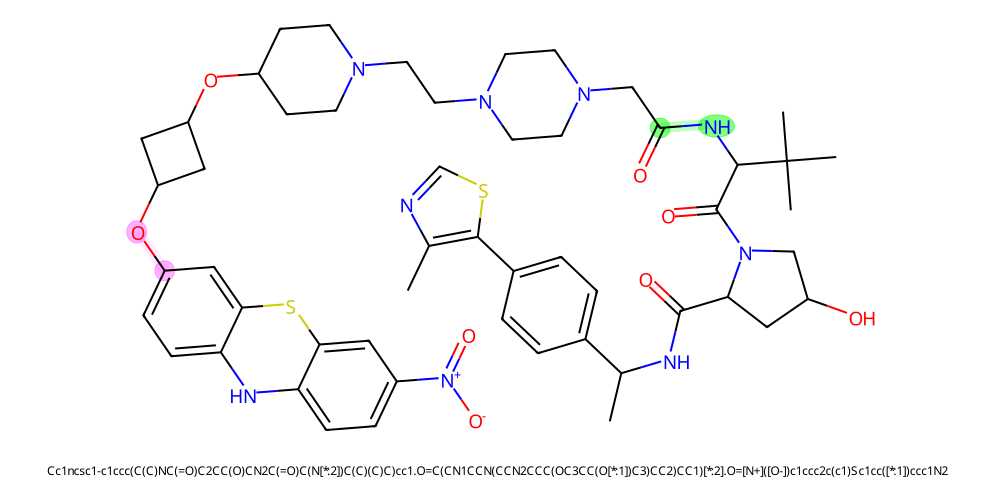

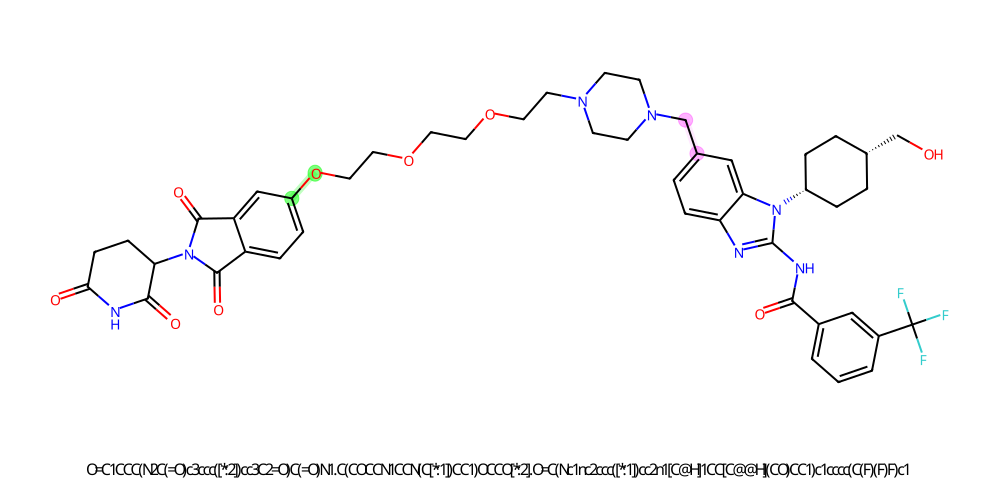

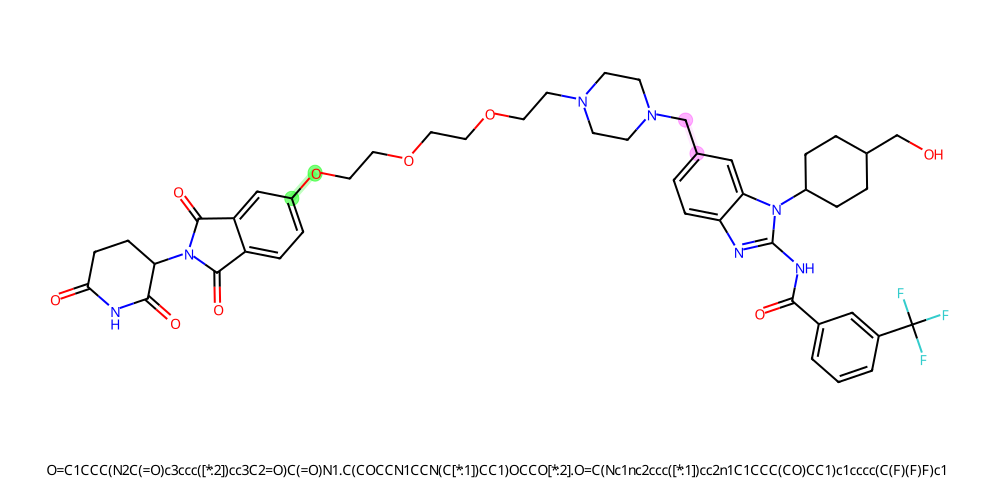

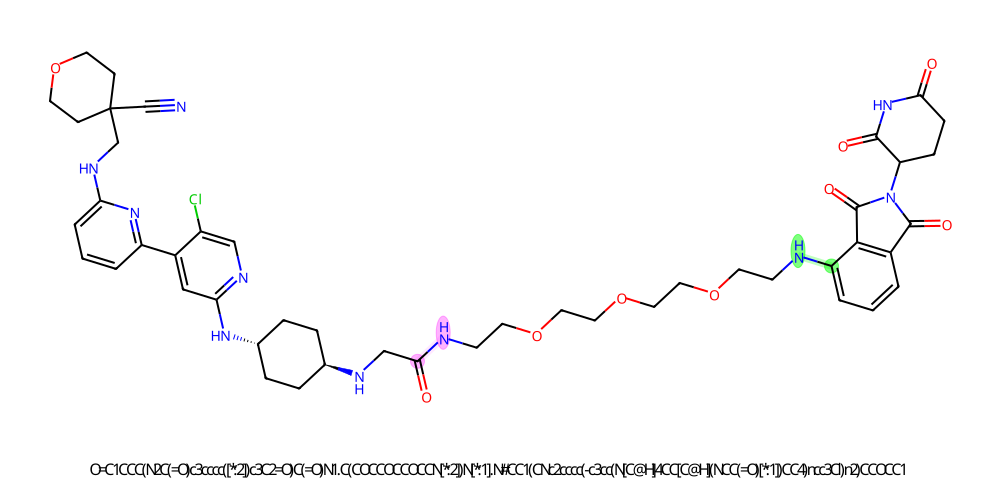

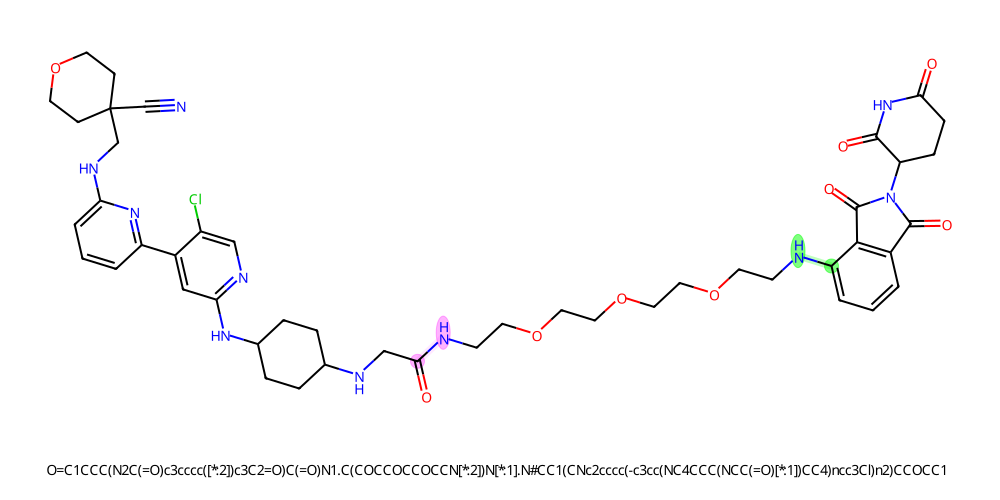

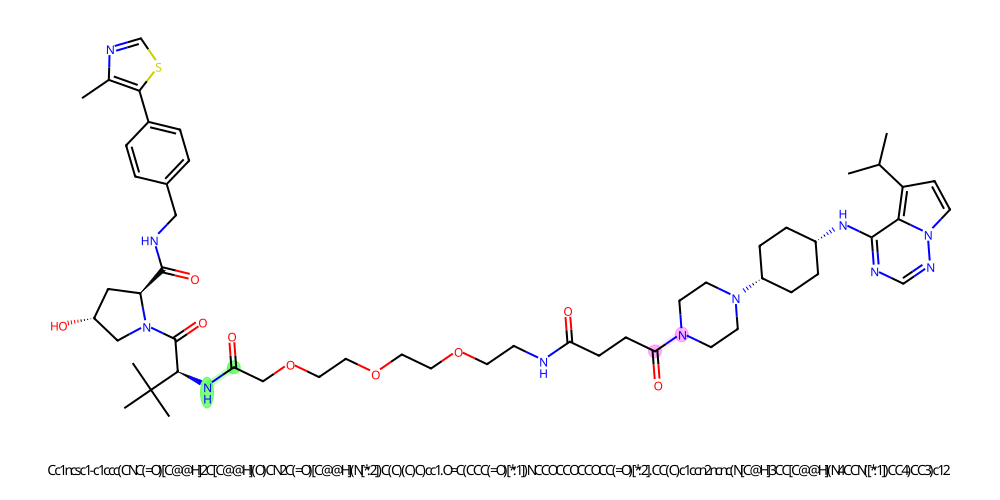

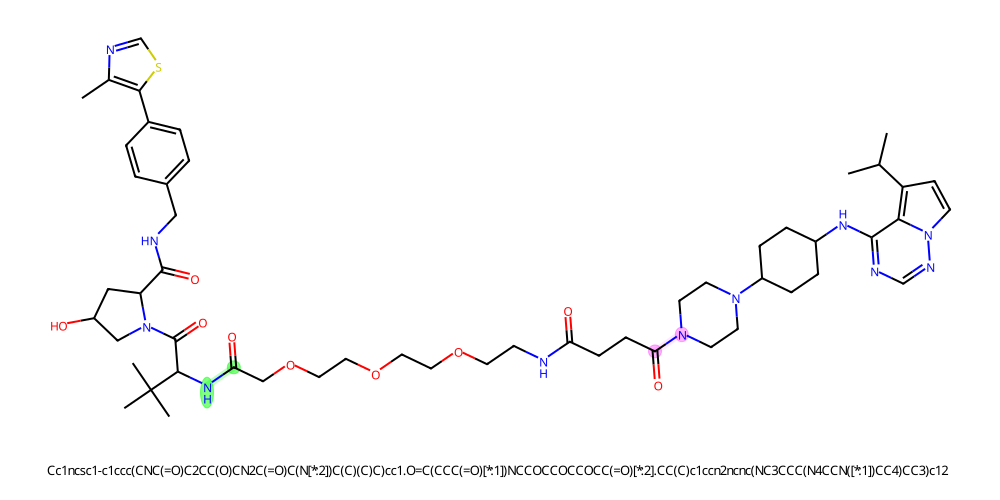

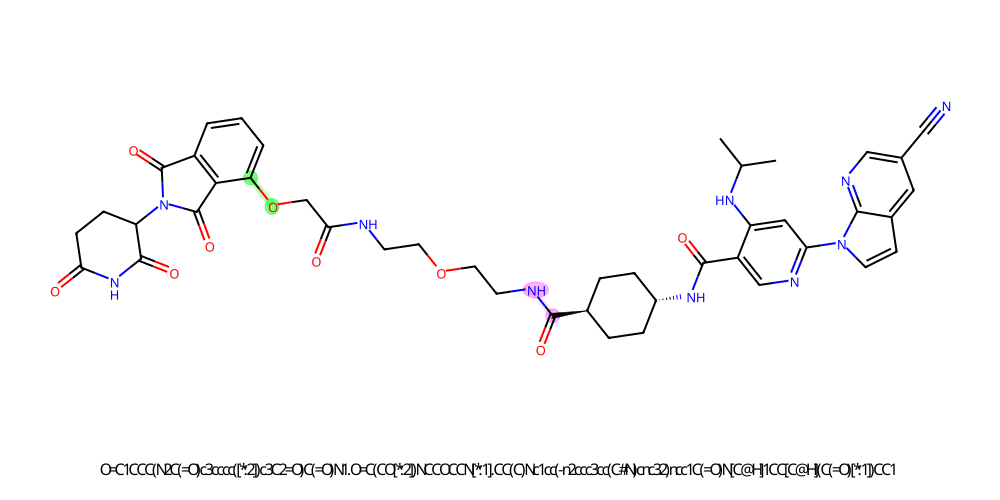

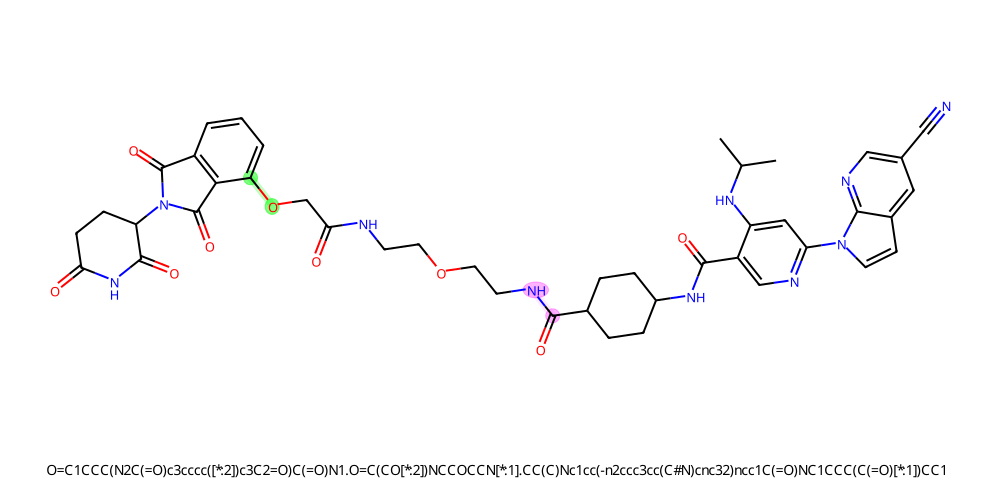

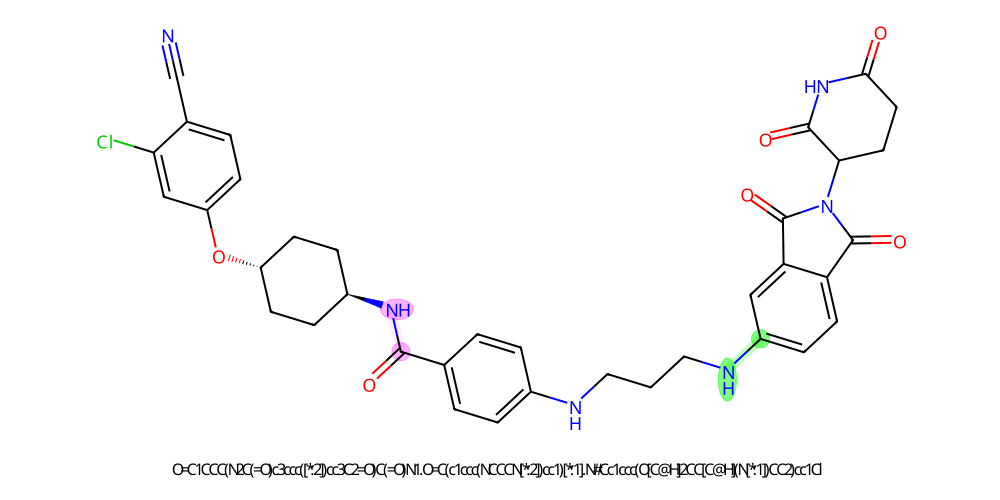

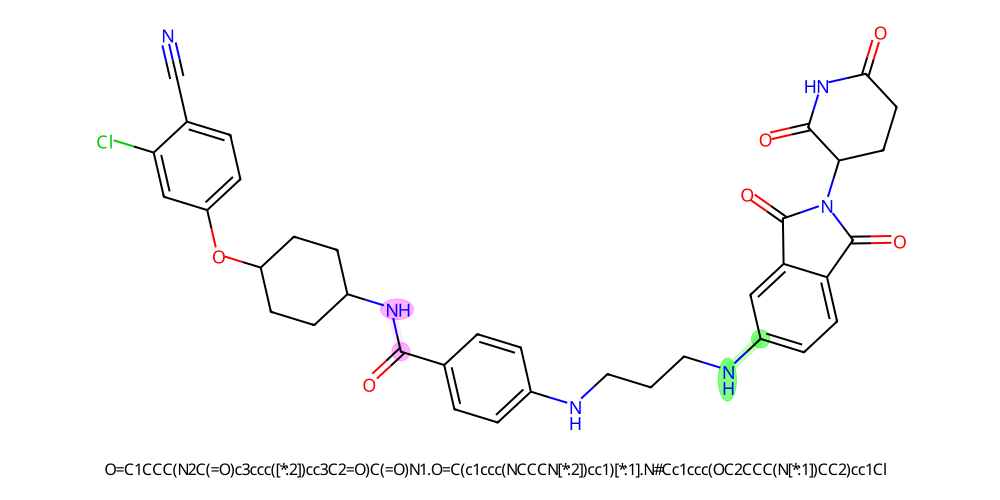

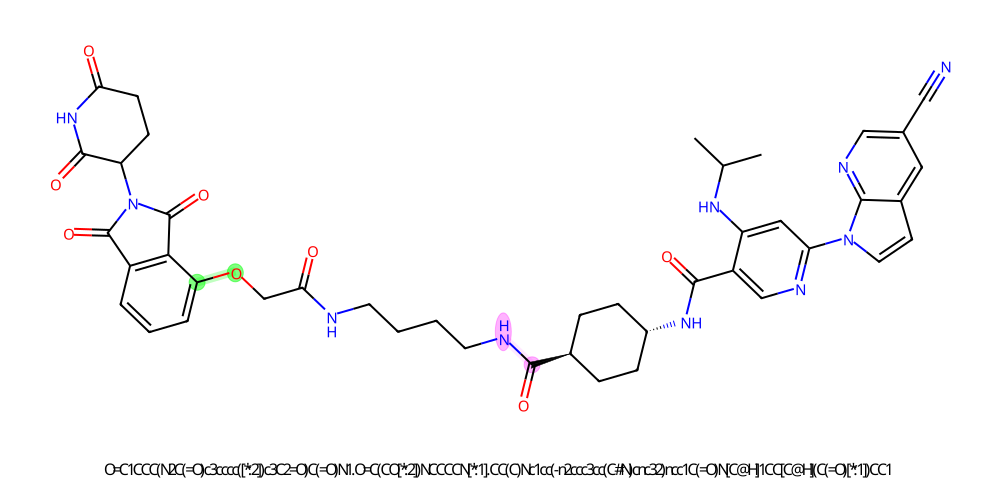

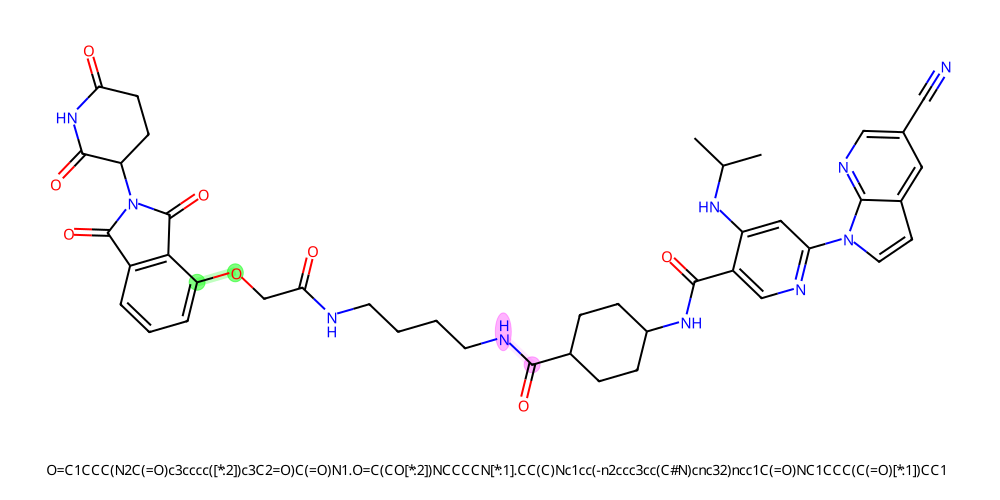

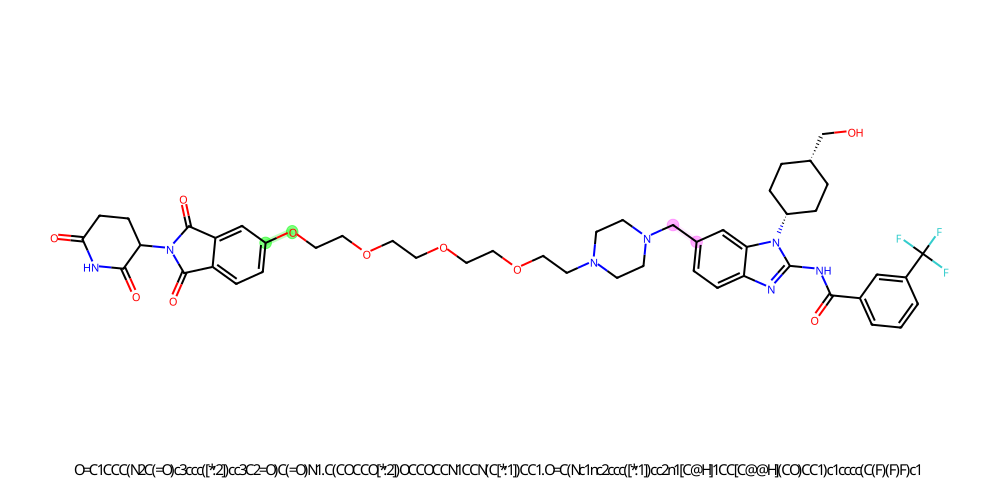

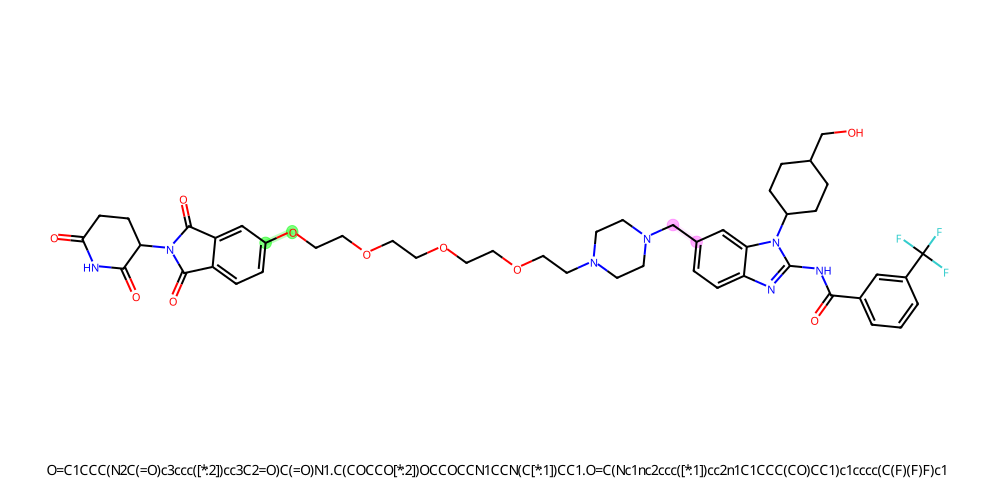

In [8]:
protacs_smiles = [
    "Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CN2CCN(CCN3CCC(O[C@H]4C[C@H](Oc5ccc6c(c5)Sc5cc([N+](=O)[O-])ccc5N6)C4)CC3)CC2)C(C)(C)C)cc1",
    "CN(c1ccc(C#N)c(Cl)c1)[C@H]1CC[C@H](NC(=O)c2ccc(N3CC(CN4CCN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)C3)cc2)CC1",
    "Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCNC(=O)CCC(=O)N2CCN([C@H]3CC[C@@H](Nc4ncnn5ccc(C(C)C)c45)CC3)CC2)C(C)(C)C)cc1",
    "CN1C(=O)CCc2cc3cc(c21)OCCOCC1CN(C(=O)CCC(=O)NCCCOCCOCCOc2cccc4c2C(=O)N(C2CCC(=O)NC2=O)C4=O)CCN1c1ncc(Cl)c(n1)N3",
    "N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl",
    "CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)NCCOCCOCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1",
    "CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)NCCCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1",
    "CN1C(=O)CCc2cc3cc(c21)OCCOC[C@H]1CN(C(=O)CCC(=O)NCCCOCCOCCOc2cccc4c2C(=O)N(C2CCC(=O)NC2=O)C4=O)CCN1c1ncc(Cl)c(n1)N3",
    "O=C1CCC(N2C(=O)c3ccc(OCCOCCOCCN4CCN(Cc5ccc6nc(NC(=O)c7cccc(C(F)(F)F)c7)n([C@H]7CC[C@@H](CO)CC7)c6c5)CC4)cc3C2=O)C(=O)N1",
    "N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl",
    "Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CNC(=O)c2cccc(-c3ccc(N4CCN(C)CC4)c(NC(=O)c4c[nH]c(=O)cc4C(F)(F)F)c3)c2)C(C)(C)C)cc1",
    "CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)NCCOCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1",
    "Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCCOCCOCCNC(=O)CCC(=O)N2CCN([C@H]3CC[C@@H](Nc4ncnn5ccc(C(C)C)c45)CC3)CC2)C(C)(C)C)cc1",
    "O=C1CCC(N2C(=O)c3ccc(OCCOCCOCCOCCN4CCN(Cc5ccc6nc(NC(=O)c7cccc(C(F)(F)F)c7)n([C@H]7CC[C@@H](CO)CC7)c6c5)CC4)cc3C2=O)C(=O)N1",
    "N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(NCCCNc4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)cc3)CC2)cc1Cl",
    "CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)NCCOCCOCCOCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1",
    "N#CC1(CNc2cccc(-c3cc(N[C@H]4CC[C@H](NCC(=O)NCCOCCOCCOCCNc5cccc6c5C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)ncc3Cl)n2)CCOCC1",
    "N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(NCCCCCCCCCNc4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)cc3)CC2)cc1Cl",
]

wh_smiles = [
    "CN1C(=O)CCc2cc3cc(c21)OCCOC[C@H]1CNCCN1c1ncc(Cl)c(n1)N3",
    "CN1C(=O)CCc2cc3cc(c21)OCCOCC1CNCCN1c1ncc(Cl)c(n1)N3",
    "CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C=O)CC1",
    "N#CC1(CNc2cccc(-c3cc(N[C@H]4CC[C@H](NCC=O)CC4)ncc3Cl)n2)CCOCC1",
    "N#Cc1ccc(O[C@H]2CC[C@H](N)CC2)cc1Cl",
    "N#Cc1ccc(O[C@H]2CC[C@H](N)CC2)cc1Cl",
    "CC(C)c1ccn2ncnc(N[C@H]3CC[C@@H](N4CCNCC4)CC3)c12",
    "CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C=O",
    "O=C(Nc1nc2ccc(CN3CCNCC3)cc2n1[C@H]1CC[C@@H](CO)CC1)c1cccc(C(F)(F)F)c1",
    "CN(c1ccc(C#N)c(Cl)c1)[C@H]1CC[C@H](N)CC1",
    "CN1CCN(c2ccc(-c3cccc(C=O)c3)cc2NC(=O)c2c[nH]c(=O)cc2C(F)(F)F)CC1",
    "N#Cc1ccc(O[C@H]2CC[C@H](N)CC2)cc1Cl",
    "CC(C)c1ccn2ncnc(N[C@H]3CC[C@@H](N4CCNCC4)CC3)c12",
    "CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C=O",
    "O=[N+]([O-])c1ccc2c(c1)Sc1ccccc1N2",
    "N#Cc1ccc(O[C@H]2CC[C@H](N)CC2)cc1Cl",
    "CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C=O)CC1",
    "O=C(Nc1nc2ccccc2n1[C@H]1CC[C@@H](CO)CC1)c1cccc(C(F)(F)F)c1",
]

e3_smiles = [
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "Nc1ccc2c(c1)C(=O)N(C1CCC(=O)NC1=O)C2=O",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(N)C(C)(C)C)cc1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
    "O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1",
]

# NOTE: The linker might not be required if the E3s and WH are of "good" quality
lk_smiles = [
    'O=C(CO[*:2])NCCOCCOCCN[*:1]',
    'O=C(CO[*:2])NCCOCCOCCN[*:1]',
    'O=C(CO[*:2])NCCCCN[*:1]',
    'O=C(CO[*:2])NCCCCN[*:1]',
    'O=C(CCC(=O)[*:1])NCCCC(=O)[*:2]',
    'O=C(CCC(=O)[*:1])NCCCC(=O)[*:2]',
    'O=C(c1ccc(N2CC(CN3CCN([*:2])CC3)C2)cc1)[*:1]',
    'O=C(c1ccc(N2CC(CN3CCN([*:2])CC3)C2)cc1)[*:1]',
    'O=C(c1ccc(N2CCN(CCCCCN[*:2])CC2)cc1)[*:1]',
    'O=C(c1ccc(N2CCN(CCCCCN[*:2])CC2)cc1)[*:1]',
    'O=C(CN[*:1])[*:2]',
    'O=C(CO[*:2])NCCOCCN[*:1]',
    'O=C(CO[*:2])NCCOCCN[*:1]',
    'O=C(CN1CCN(CCN2CCC(O[C@H]3C[C@H](O[*:1])C3)CC2)CC1)[*:2]',
    'O=C(CN1CCN(CCN2CCC(OC3CC(O[*:1])C3)CC2)CC1)[*:2]',
    'C(COCCOCCOCCN[*:2])N[*:1]',
    'C(COCCOCCOCCN[*:2])N[*:1]',
    'O=C(CO[*:2])NCCOCCOCCOCCN[*:1]',
    'O=C(CO[*:2])NCCOCCOCCOCCN[*:1]',
    'O=C(CCC(=O)[*:1])NCCCOCCOCCO[*:2]',
    'O=C(CCC(=O)[*:1])NCCCOCCOCCO[*:2]',
    'O=C(c1ccc(NCCCN[*:2])cc1)[*:1]',
    'O=C(c1ccc(NCCCN[*:2])cc1)[*:1]',
    'O=C(c1ccc(N2CCN(CCCCN[*:2])CC2)cc1)[*:1]',
    'O=C(c1ccc(N2CCN(CCCCN[*:2])CC2)cc1)[*:1]',
    'O=C(CCC(=O)[*:1])NCCOCCOCCOCC(=O)[*:2]',
    'O=C(CCC(=O)[*:1])NCCOCCOCCOCC(=O)[*:2]',
    'C(COCCO[*:2])OCCOCCN1CCN(C[*:1])CC1',
    'C(COCCO[*:2])OCCOCCN1CCN(C[*:1])CC1',
    'O=C(c1ccc(NCCCCCCCCCN[*:2])cc1)[*:1]',
    'O=C(c1ccc(NCCCCCCCCCN[*:2])cc1)[*:1]',
    'C(COCCN1CCN(C[*:1])CC1)OCCO[*:2]',
    'C(COCCN1CCN(C[*:1])CC1)OCCO[*:2]',
 ]

# We will update an "empty" dictionary
dictionaries = {
    'PROTAC': update_dictionary(pd.DataFrame(), protacs_smiles),
    'E3 Binder': update_dictionary(pd.DataFrame(), e3_smiles),
    'POI Ligand': update_dictionary(pd.DataFrame(), wh_smiles),
    'Linker': pd.DataFrame(), # One can decide to include the linkers or not
}

split_protacs_df = split_protacs(
    dictionaries['PROTAC'],
    dictionaries=dictionaries,
    split_with_substr_and_linker_matching=False,
    max_iter_on_linkers=0, # This argument will turn off the linker matching
    use_multiprocessing=False, # It might be useful for a large number of PROTACs, in the order of 10K
)

display(split_protacs_df)

print("-" * 80)
print("List of split PROTACs:")
print("-" * 80)
for i, row in split_protacs_df.iterrows():
    print(f"    [")
    print(f"        '{row['PROTAC SMILES']}',")
    print(f"        '{row['E3 Binder SMILES with direction']}.{row['Linker SMILES with direction']}.{row['POI Ligand SMILES with direction']}',")
    print(f"    ],")
print("-" * 80)

print("Displaying split PROTACs:")
print("-" * 80)
for i, row in split_protacs_df.iterrows():
    get_mapped_protac_img(
        protac_smiles=row['PROTAC SMILES'],
        e3_smiles=row['E3 Binder SMILES with direction'],
        poi_smiles=row['POI Ligand SMILES with direction'],
        linker_smiles=row['Linker SMILES with direction'],
        display_image=True,
        useSVG=True,
        w=1000,
        h=500,
    )

In [ ]:
dictionaries = {
    'PROTAC': update_dictionary(pd.DataFrame(), protacs_smiles),
    'E3 Binder': update_dictionary(pd.DataFrame(), e3_smiles),
    'POI Ligand': update_dictionary(pd.DataFrame(), wh_smiles),
    'Linker with direction': update_dictionary(pd.DataFrame(), lk_smiles),
}

updated_dictionaries = iterative_protac_splitting(
    dictionaries=dictionaries,
    data_dir='/tmp',
)

# print(updated_dictionaries)

print("-" * 80)
print("List of split PROTACs:")
print("-" * 80)
for k, dictionary in updated_dictionaries.items():
    print(f"{k}: {len(dictionary)}")

----------------------------------------------------------------------------------------------------
Step n.0
Max iterations on linkers: 0
Map with substr and linker matching: False
--------------------------------------------------


PROTAC n.  32: 100%|██████████| 33/33 [00:00<00:00, 44.44it/s, len_mapped=33, perc_mapped=100.0%]


All mapped PROTACs saved to: /tmp/mapped_protacs.csv
Number of mapped PROTACs:     33 (100.00%)
Total num. of mapped PROTACs: 33 (100.00%)
--------------------------------------------------
Notes
(max_iter_on_linkers=0)(split_with_substr_and_linker_matching=False)(morgan_radius=2)(morgan_fp_size=2048)(matching_poi=True)(matching_e3=True)(matching_linker=None)(amide_bonds_fixed=False)(ester_bonds_fixed=False)(step=0)    33
Name: count, dtype: int64
--------------------------------------------------
Non-mapped PROTACs saved to: /tmp/non_mapped_protacs.csv
Dictionary saved to: /tmp/dictionary_protac.csv
Dictionary saved to: /tmp/dictionary_e3_binder.csv
Dictionary saved to: /tmp/dictionary_poi_ligand.csv
Dictionary saved to: /tmp/dictionary_linker_with_direction.csv
--------------------------------------------------------------------------------
List of split PROTACs:
--------------------------------------------------------------------------------
PROTAC: 33
E3 Binder: 6
POI Ligand: 19
Li